# ARTIFICIAL NEURAL NETWORKS

### Classification Using Artificial Neural Networks with Hyperparameter Tuning on Alphabets Data

## Overview
### In this assignment, you will be tasked with developing a classification model using Artificial Neural Networks (ANNs) to classify data points from the "Alphabets_data.csv" dataset into predefined categories of alphabets. This exercise aims to deepen your understanding of ANNs and the significant role hyperparameter tuning plays in enhancing model performance.

## Dataset: "Alphabets_data.csv"
### The dataset provided, "Alphabets_data.csv", consists of labeled data suitable for a classification task aimed at identifying different alphabets. Before using this data in your model, you'll need to preprocess it to ensure optimal performance.

## Tasks

## Step-by-Step ANN Classification with Hyperparameter Tuning
### 1. Load & Explore Data

In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv("Alphabets_data.csv")

# Explore
print(data.shape)        # rows, columns
print(data.head())       # first few rows
print(data.columns)      # column names
print(data['letter'].unique())  # target classes

(20000, 17)
  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybar  xy2bar  xedge  xedgey  yedge  yedgex  
0      10       8      0       8      0       8  
1       3       9      2       8      4      10  
2       3       7      3       7      3       9  
3       4      10      6      10      2       8  
4       5       9      1       7      5      10  
Index(['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar',
       'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 'xedge', 'xedgey',
       'yedge', 'yedgex'],
      dtype='object')
['T' 'I' 'D' '

## 2. Preprocessing

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and target
X = data.drop('letter', axis=1)   # features
y = data['letter']                # target

# Encode labels (A, B, C... → numbers)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)
print(X_train.shape, '\n', X_test.shape)
print(len(encoder.classes_))


(16000, 16) 
 (4000, 16)
26


## 3. Build & Train Basic ANN

In [3]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(encoder.classes_), activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                    validation_split=0.2, verbose=1)
# print("Best params:", grid_result.best_params_)
print("Final training accuracy:", history.history['accuracy'][-1])
print("Final validation accuracy:", history.history['val_accuracy'][-1])

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4691 - loss: 1.9794 - val_accuracy: 0.6753 - val_loss: 1.1835
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7206 - loss: 0.9702 - val_accuracy: 0.7447 - val_loss: 0.8817
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7749 - loss: 0.7685 - val_accuracy: 0.7797 - val_loss: 0.7490
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8037 - loss: 0.6563 - val_accuracy: 0.8028 - val_loss: 0.6541
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8273 - loss: 0.5776 - val_accuracy: 0.8250 - val_loss: 0.5834
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8470 - loss: 0.5172 - val_accuracy: 0.8391 - val_loss: 0.5309
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8617 - loss: 0.4672 - val_accuracy: 0.8553 - val_loss: 0.4918
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8752 - loss: 0.4261 - val_accuracy: 0.

## 4. Hyperparameter Tuning (GridSearch)

In [4]:
# !pip install scikeras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input


def create_model(optimizer='adam', activation='relu'):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation=activation),
        Dense(32, activation=activation),
        Dense(len(encoder.classes_), activation='softmax')
    ])
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Wrap model
model = KerasClassifier(model=create_model, verbose=0)

# Define grid
param_grid = {
    'model__optimizer': ['adam', 'sgd'],
    'model__activation': ['relu', 'tanh'],
    'batch_size': [32, 64],
    'epochs': [10, 20]
}

# Run GridSearch
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid_result = grid.fit(X_train, y_train)

# print("Best params:", grid_result.best_params_)
print("Best params:", grid_result.best_params_)
print("Best score:", grid_result.best_score_)

# See all results
import pandas as pd
results_df = pd.DataFrame(grid_result.cv_results_)
print(results_df[['param_model__optimizer', 'param_model__activation', 'param_batch_size', 'param_epochs', 'mean_test_score']])

Best params: {'batch_size': 32, 'epochs': 20, 'model__activation': 'relu', 'model__optimizer': 'adam'}
Best score: 0.9035624367505347
   param_model__optimizer param_model__activation  param_batch_size  \
0                    adam                    relu                32   
1                     sgd                    relu                32   
2                    adam                    tanh                32   
3                     sgd                    tanh                32   
4                    adam                    relu                32   
5                     sgd                    relu                32   
6                    adam                    tanh                32   
7                     sgd                    tanh                32   
8                    adam                    relu                64   
9                     sgd                    relu                64   
10                   adam                    tanh                64   
11            

## 5. Evaluation

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predictions with tuned model
y_pred = grid_result.best_estimator_.predict(X_test)

# Metrics
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.98      0.97       149
           1       0.84      0.93      0.88       153
           2       0.97      0.93      0.95       137
           3       0.87      0.94      0.90       156
           4       0.84      0.96      0.90       141
           5       0.88      0.91      0.89       140
           6       0.90      0.91      0.90       160
           7       0.93      0.79      0.86       144
           8       0.94      0.92      0.93       146
           9       0.96      0.92      0.94       149
          10       0.89      0.88      0.89       130
          11       0.97      0.95      0.96       155
          12       0.96      0.96      0.96       168
          13       0.97      0.90      0.93       151
          14       0.91      0.96      0.94       145
          15       0.94      0.91      0.93       173
          16       0.99      0.95      0.97       166
          17       0.81    

## 6. Visualization (Optional but great for your report)

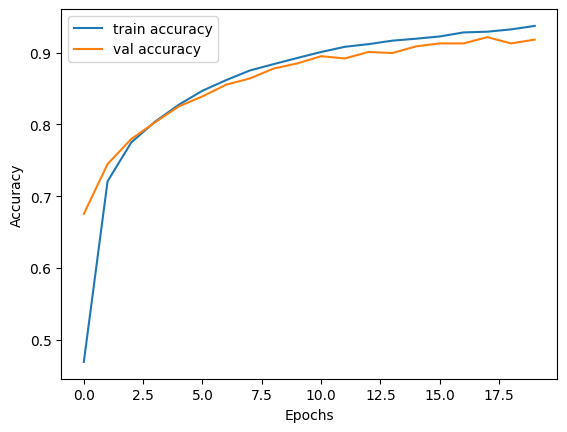

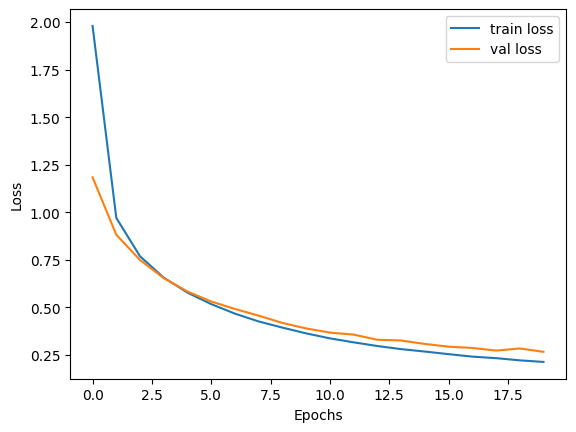

In [6]:
import matplotlib.pyplot as plt

# Plot training history
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()